## writing backward pass manually

In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
words = open('../words.txt', 'r').read().splitlines()
words[:8]

['abakus',
 'abandon',
 'abazja',
 'abażur',
 'abażurek',
 'abdukcja',
 'abduktor',
 'abdykacja']

In [7]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [8]:
block_size = 3  # context size

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [9]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

torch.Size([400292, 3]) torch.Size([400292])
torch.Size([50134, 3]) torch.Size([50134])
torch.Size([50015, 3]) torch.Size([50015])


In [10]:
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [11]:
n_emb = 10
n_hidden = 64

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g) * (5/3) / ((30)**0.5)
b1 = torch.rand(n_hidden, generator=g) * 0.1       # it's useless
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.zeros(vocab_size) * 0.1

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print("number of parameters: ", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

number of parameters:  4598


In [12]:
batch_size = 32
n = batch_size
ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
Xb, Yb = X_train[ix], Y_train[ix]

1) mean  
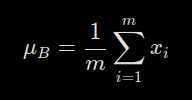  
2) variation  
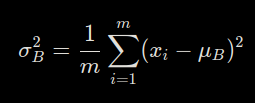
3) normalization  
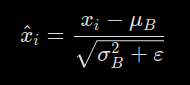  
4) scaling and shifting  
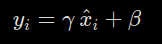

μ - mean over a batch (bnmeani)  
σ^2 - variation over the batch (bnvar)  

In [ ]:
# FORWARD PASS

emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)

# linear layer 1
hprebn = embcat @ W1 + b1   # it's just x, input to batchnorm (activations before normalization)  torch.Size([32, 64])

# batch norm layer
# 1) mean
bnmeani = 1/n*hprebn.sum(0, keepdim=True)       # mean values over the first dimension  torch.Size([1, 64])
bndiff = hprebn - bnmeani                       # (x−μ) broadcasting  torch.Size([32, 64])
# 2) variation
bndiff2 = bndiff**2                             # we need it only for bnvar
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True)  # variation (with Bessel's correction)
# 3) normalization
bnvar_inv = (bnvar + 1e-5)**(-0.5)              # denominator of the normalization (1e-5 for numerical stability)
bnraw = bndiff * bnvar_inv                      # (numerator * denominator) bnraw is normalized input
# 4) scaling and shifting
hpreact = bngain * bnraw + bnbias               # shifting and scaling applied

# non-linearity
h = torch.tanh(hpreact)     # hidden layer

# linear layer 2
logits = h @ W2 + b2

# cross entropy loss
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes          # substract max for numerical stability
counts = norm_logits.exp()                  # logits to positive values that can then be normalized to probabilities
counts_sum = counts.sum(1, keepdim=True)    # sum
counts_sum_inv = counts_sum**(-1)           # 1/sum
probs = counts * counts_sum_inv             # we need to divide every row by it's sum to normalize the counts to make them probs (counts * 1/sum)
logprobs = probs.log()                      # -log(p) penalizes more then 1-p
loss = -logprobs[range(n), Yb].mean()       # -mean of logprobs

# PyTorch backward pass (to check if we calculated correctly)
for p in parameters:
    p.grad = None

for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.5049, grad_fn=<NegBackward0>)